## Assignment 5

Due April 15, 2026

Ian Solberg

Professor Piao

## Part 1


In [ ]:
FULL_SETUP = False

In [2]:
# ============================================================
# SETUP — Run this cell first
# ============================================================

# Uncomment and run once if packages are missing:
# !pip install wbgapi scikit-learn matplotlib seaborn numpy pandas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, lasso_path
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import wbgapi as wb

# Reproducibility
np.random.seed(42)

print("Setup complete ✓")

Setup complete ✓


In [3]:
# ============================================================
# PART 1A: Download World Bank Data
# ============================================================

# WDI indicator codes for our predictors
# Format: 'indicator_code': 'human_readable_name'
INDICATORS = {
    # Growth outcome (our y)
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',

    # Trade & Openness
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':    'royalties_receipts',

    # Macroeconomics
    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR':       'real_interest_rate',
    'PA.NUS.FCRF':       'exchange_rate_official',

    # Education & Human Capital
    'SE.SEC.ENRR':       'secondary_enrollment_gross',
    'SE.TER.ENRR':       'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',

    # Infrastructure & Technology
    'IT.NET.USER.ZS':    'internet_users_pct',
    'IT.CEL.SETS.P2':    'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS':    'electricity_access_pct',
    'IS.ROD.PAVE.ZS':    'paved_roads_pct',

    # Health & Demographics
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.DYN.MORT':       'infant_mortality_per1000',
    'SP.POP.GROW':       'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',

    # Finance & Banking
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':    'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',

    # Natural Resources
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':    'renewable_energy_pct',
    'EN.ATM.CO2E.PC':    'co2_emissions_per_capita',

    # Agriculture
    'NV.AGR.TOTL.ZS':    'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':    'arable_land_pct',

    # Governance (World Bank Governance Indicators)
    'IQ.CPA.TRAD.XQ':    'trade_cpia',
    'IQ.CPA.FINS.XQ':    'financial_management_cpia',
    'IQ.CPA.PROP.XQ':    'property_rights_cpia',
}

OUTCOME_VAR = 'gdp_growth_pc'
indicator_list = list(INDICATORS.keys())

print(f"Downloading {len(indicator_list)} indicators for all countries, 2013–2019...")
print("(This may take 30–60 seconds — API call to World Bank)")

# Download 7 years of data (2013–2019, pre-COVID) and average
# wb.data.DataFrame returns a DataFrame indexed by (economy, time) or (economy)
try:
    raw_data = wb.data.DataFrame(
        indicator_list,
        time=["YR2013", "YR2014", "YR2015", "YR2016", "YR2017", "YR2018", "YR2019"],  # 2013–2019
        skipBlanks=True,
        labels=False
    )
    raw_data.columns = [INDICATORS[c] if c in INDICATORS else c for c in raw_data.columns]
    print(f"Raw data shape: {raw_data.shape}")
    print("Download successful ✓")
except Exception as e:
    print(f"API error: {e}")
    print("Loading fallback data from CSV...")
    # Fallback: load pre-downloaded CSV
    # raw_data = pd.read_csv('data/fallback_wdi_topic16.csv', index_col=[0, 1])

(This may take 30–60 seconds — API call to World Bank)
Raw data shape: (7211, 7)
Download successful ✓


In [14]:
## Make Backup CSV
EXPORT_CSV = True
if EXPORT_CSV:
    raw_data.to_csv('./data/wdi_topic16_raw.csv')
    print("Raw data saved to './data/wdi_topic16_raw.csv' ✓")
else:
    pass

Raw data saved to './data/wdi_topic16_raw.csv' ✓


📦 Shared Data Pipeline

All four phases of this assignment use the same World Bank dataset. Build this data pipeline first before attempting any phase. The code below downloads 30+ WDI indicators for ~150 countries (2013–2019 averages), constructs the binary crisis outcome, and splits into train/test sets. You may reuse the indicator dictionary and download logic from Lab 16 as your starting point.

Required steps:

1. Download the same WDI indicators used in Lab 16 via wbgapi (2013–2019). You may add or remove indicators, but retain at least 25 predictors.
2. Collapse to country-level means. Drop countries missing >40% of indicators. Drop indicators missing >40% of countries. Median-impute remaining gaps.
3. Define the continuous outcome: gdp_growth_pc (average GDP per capita growth rate).
4. Define the binary crisis outcome: crisis = 1 if gdp_growth_pc < 0 (negative average growth), else crisis = 0. This identifies countries that experienced sustained economic contraction during the period.
5. Perform a 70/30 train-test split with random_state=42. Standardize features using StandardScaler fit on training data only.
6. Print the final dataset dimensions, the number of crisis vs. non-crisis countries, and the crisis base rate. You will reference these numbers throughout the assignment.

In [47]:
# full_data 

data = pd.read_csv('./data/wdi_topic16_raw.csv', index_col=[0, 1])

# drop ROWS (country-year) missing more than 40% of indicators
data = data.dropna(thresh=int(len(data.columns) * 0.6))

# drop COLUMNS (indicators) missing more than 40% of country-year rows
data = data.dropna(axis=1, thresh=int(len(data) * 0.6))
# column's median imputation for remaining missing values
for col in data.columns:
    if data[col].isnull().any():
        median_value = data[col].median()
        data[col].fillna(median_value, inplace=True)

# define crisis binary variable: 1 if gdp_growth_pc < 0, else 0

data = data.reset_index()
data["series"] = data["series"].map(INDICATORS)
data["Avg_Across_Years"] = (data["YR2013"] + data["YR2014"] + data["YR2015"] + data["YR2016"] + data["YR2017"] + data["YR2018"] + data["YR2019"]) / 7
data.drop(columns=["YR2013", "YR2014", "YR2015", "YR2016", "YR2017", "YR2018", "YR2019"], inplace=True)

pivot_data = data.pivot(index="economy", columns="series", values="Avg_Across_Years")
pivot_data = pivot_data.reset_index()
data = pivot_data

null_counts = data.isnull().sum()
s = null_counts.sort_values(ascending=False)
top_10_missing = s.head(10)

data.drop(columns=top_10_missing.index, inplace=True)

# drop rows with over 40% of indicators missing
data = data.dropna(thresh=int(len(data.columns) * 0.6))


# impute median for remaining missing values
for col in data.columns:
    if data[col].isnull().any():
        median_value = data[col].median()
        data[col].fillna(median_value, inplace=True)

data

series,economy,agriculture_pct_gdp,arable_land_pct,atms_per100k,current_account_pct_gdp,education_expenditure_pct_gdp,electricity_access_pct,exchange_rate_official,fdi_inflows_pct_gdp,gdp_growth_pc,...,mobile_subscriptions_per100,natural_resource_rents_pct_gdp,population_growth,private_credit_pct_gdp,renewable_energy_pct,secondary_enrollment_gross,tertiary_enrollment_gross,trade_pct_gdp,unemployment_rate,urbanization_pct
0,ABW,0.018337,11.111111,123.843123,-0.669091,5.301927,100.000000,1.790000,3.551600,2.245502,...,82.569075,0.002544,0.682293,58.016290,7.314286,87.451191,15.636665,143.586678,5.997641,62.988008
1,AFE,12.439481,8.096816,8.029037,-2.504571,4.677735,37.718154,9.296977,1.994010,0.223588,...,63.760556,8.058552,2.698276,37.151340,61.605147,42.748069,8.517323,55.661535,7.096626,34.887403
2,AFG,23.651344,11.900053,1.128242,-19.805290,6.630998,87.928571,65.640378,0.415848,-0.272302,...,59.471626,0.639170,3.058566,3.676093,18.657143,48.900154,41.795275,68.827673,9.792429,24.585807
3,AFW,20.565694,11.932068,4.864819,-2.504571,2.888076,49.199649,9.296977,2.024465,0.649231,...,83.144219,8.907769,2.633388,13.585211,75.868295,43.429490,9.424783,68.827673,4.134629,48.171470
4,AGO,12.971708,4.166084,17.853955,0.248949,4.343463,41.142857,180.305048,-1.996599,-2.476583,...,46.957928,24.658383,3.592279,16.293914,49.357143,87.451191,41.795275,59.174363,16.513714,64.327626
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,XKX,7.679652,10.290698,37.953147,-6.549505,4.544362,98.257143,0.847941,4.155577,4.894998,...,106.008891,0.476781,-0.144884,37.870711,21.826584,87.451191,41.795275,79.099632,5.997641,41.015851
261,YEM,21.429892,2.185189,37.104888,2.660440,4.544362,70.285714,275.475013,1.233748,-5.737458,...,49.731208,6.844108,3.013613,44.093284,2.157143,87.451191,41.795275,39.270925,16.696714,33.045844
262,ZAF,2.200798,9.892094,65.271669,-3.584226,5.560266,84.914286,12.711773,1.132043,-0.206104,...,150.889295,4.148530,1.464327,60.977948,7.914286,90.436272,20.105547,56.126001,26.220714,63.256194
263,ZMB,5.205943,5.034850,10.457532,-1.792251,4.304333,35.428571,9.050807,4.548347,0.479478,...,75.543559,11.227596,3.089186,12.569384,84.471429,87.451191,41.795275,75.105549,5.734571,42.337474


In [51]:
data.isna().sum()

series
economy                           0
agriculture_pct_gdp               0
arable_land_pct                   0
atms_per100k                      0
current_account_pct_gdp           0
education_expenditure_pct_gdp     0
electricity_access_pct            0
exchange_rate_official            0
fdi_inflows_pct_gdp               0
gdp_growth_pc                     0
govt_expenditure_pct_gdp          0
health_expenditure_pct_gdp        0
infant_mortality_per1000          0
inflation_cpi                     0
internet_users_pct                0
life_expectancy                   0
mobile_subscriptions_per100       0
natural_resource_rents_pct_gdp    0
population_growth                 0
private_credit_pct_gdp            0
renewable_energy_pct              0
secondary_enrollment_gross        0
tertiary_enrollment_gross         0
trade_pct_gdp                     0
unemployment_rate                 0
urbanization_pct                  0
dtype: int64

In [48]:
OUTCOME_VAR = 'gdp_growth_pc'

In [52]:
# === 70 / 30 train-test split ===

X = data.drop(columns=[OUTCOME_VAR, "economy"])
y = data[OUTCOME_VAR]

# Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


## Phase 1: The Complexity Trap — OLS Failure and Regularization Rescue
Labs assessed: Lab 15 (Bias-Variance Tradeoff) & Lab 16 (Ridge, Lasso, Lasso Path)

### Step 1.1: Demonstrating OLS Overfitting
Before proposing any fix, you must first prove that the existing OLS model is broken. Fit an OLS LinearRegression on all standardized predictors to forecast gdp_growth_pc.

Deliverables:

Print Training R² and Test R². Compute the Train–Test R² gap.
Print the predictor-to-observation ratio (p/n) for the training set.
Written response (2–3 sentences): Connect the p/n ratio to the R² gap. Why does a high p/n ratio cause OLS to overfit? Use the terms bias, variance, and degrees of freedom in your explanation.


### Step 1.2: Ridge and Lasso to the Rescue
Apply both RidgeCV and LassoCV with 5-fold cross-validation to the same prediction task.

Deliverables:

For each model, report: the CV-selected λ* (.alpha_), the number of non-zero coefficients, Training R², and Test R².
Construct a model comparison table (as a printed DataFrame) with rows for OLS, Ridge, and Lasso, and columns for λ*, Non-zero Predictors, Training R², Test R², and Test RMSE.
Written response (2–3 sentences): Which model would you recommend to the IMF Director for operational GDP growth forecasting? Justify using the bias-variance tradeoff: explain what Ridge and Lasso each sacrifice (in terms of bias) to gain (in terms of variance reduction).


### Step 1.3: The Lasso Path — Which Indicators Enter First?
Use sklearn.linear_model.lasso_path to compute the full Lasso coefficient path across a grid of λ values.

Deliverables:

Plot the Lasso Path: all coefficient trajectories as a function of log(λ). Color the lines that are non-zero at your CV-selected λ*; gray out the rest. Overlay a vertical dashed line at λ*.
Identify the first predictor to enter the model (the one whose coefficient leaves zero at the highest λ). Name it and explain why this indicator might be the strongest unconditional predictor of cross-country growth.
Written response (3–4 sentences): A World Bank colleague argues: “Lasso zeroed out life_expectancy, so health is irrelevant to economic growth.” Explain why this interpretation is wrong. Use the terms conditional predictive redundancy and correlation structure.

In [56]:
# step 1.1 Demonstrate OLS overfitting failure with all indicators using train/test split:

ols_model = LinearRegression()
ols_model.fit(X_train, y_train)
y_pred_ols = ols_model.predict(X_test)
mse_ols = mean_squared_error(y_test, y_pred_ols)
r2_ols = r2_score(y_test, y_pred_ols)

## show training vs. test performance
y_train_pred_ols = ols_model.predict(X_train)
mse_ols_train = mean_squared_error(y_train, y_train_pred_ols)
r2_ols_train = r2_score(y_train, y_train_pred_ols)
print(f"OLS Train MSE: {mse_ols_train:.4f}")
print(f"OLS Train R²: {r2_ols_train:.4f}")

print(f"OLS Test MSE: {mse_ols:.4f}")
print(f"OLS Test R²: {r2_ols:.4f}")

# r^2 and MSE gaps 
mse_gap = mse_ols - mse_ols_train
r2_gap = r2_ols_train - r2_ols
print(f"OLS MSE gap (test - train): {mse_gap:.4f}")
print(f"OLS R² gap (train - test): {r2_gap:.4f}")
# (p/n ratio)

p = X_train.shape[1]
n = X_train.shape[0]
print(f"Number of predictors (p): {p}")
print(f"Number of observations (n): {n}")
print(f"p/n ratio: {p/n:.2f}")


OLS Train MSE: 3.6812
OLS Train R²: 0.3757
OLS Test MSE: 6.2181
OLS Test R²: 0.1039
OLS MSE gap (test - train): 2.5369
OLS R² gap (train - test): 0.2718
Number of predictors (p): 24
Number of observations (n): 175
p/n ratio: 0.14


##### response

clear example of overfitting, r^2 drops steeply

In [61]:
"""### Step 1.2: Ridge and Lasso to the Rescue
Apply both RidgeCV and LassoCV with 5-fold cross-validation to the same prediction task.

Deliverables:

For each model, report: the CV-selected λ* (.alpha_), the number of non-zero coefficients, Training R², and Test R².
Construct a model comparison table (as a printed DataFrame) with rows for 
OLS, Ridge, and Lasso, and columns for λ*, Non-zero Predictors, Training R², Test R², and Test RMSE.
"""

# Ridge Regression with Cross-Validation
ridge_cv = RidgeCV(alphas=np.logspace(-4, 4, 100), cv=5)
ridge_cv.fit(X_train, y_train)
ridge_alpha = ridge_cv.alpha_
ridge_nonzero = np.sum(ridge_cv.coef_ != 0)
y_pred_ridge = ridge_cv.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

ridge_selected_features = X_train.columns[ridge_cv.coef_ != 0]
print(f"Ridge selected features: {list(ridge_selected_features)}")
# Lasso Regression with Cross-Validation
lasso_cv = LassoCV(alphas=np.logspace(-4, 4, 100), cv=5, max_iter=10000)
lasso_cv.fit(X_train, y_train)
lasso_alpha = lasso_cv.alpha_
lasso_nonzero = np.sum(lasso_cv.coef_ != 0)
y_pred_lasso = lasso_cv.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
lasso_selected_features = X_train.columns[lasso_cv.coef_ != 0]
print(f"Lasso selected features: {list(lasso_selected_features)}")
# OLS metrics for comparison
ols_nonzero = np.sum(ols_model.coef_ != 0) # OLS has all predictors non-zero
# Model comparison table
comparison_df = pd.DataFrame({
    'Model': ['OLS', 'Ridge', 'Lasso'],
    'Lambda (α*)': ['N/A', f"{ridge_alpha:.4e}", f"{lasso_alpha:.4e}"],
    'Non-zero Predictors': [ols_nonzero, ridge_nonzero, lasso_nonzero],
    'Training R²': [r2_ols_train, ridge_cv.score(X_train, y_train), lasso_cv.score(X_train, y_train)],
    'Test R²': [r2_ols, r2_ridge, r2_lasso],
    'Test RMSE': [np.sqrt(mse_ols), np.sqrt(mse_ridge), np.sqrt(mse_lasso)]
})

comparison_df

Ridge selected features: ['agriculture_pct_gdp', 'arable_land_pct', 'atms_per100k', 'current_account_pct_gdp', 'education_expenditure_pct_gdp', 'electricity_access_pct', 'exchange_rate_official', 'fdi_inflows_pct_gdp', 'govt_expenditure_pct_gdp', 'health_expenditure_pct_gdp', 'infant_mortality_per1000', 'inflation_cpi', 'internet_users_pct', 'life_expectancy', 'mobile_subscriptions_per100', 'natural_resource_rents_pct_gdp', 'population_growth', 'private_credit_pct_gdp', 'renewable_energy_pct', 'secondary_enrollment_gross', 'tertiary_enrollment_gross', 'trade_pct_gdp', 'unemployment_rate', 'urbanization_pct']
Lasso selected features: ['arable_land_pct', 'atms_per100k', 'electricity_access_pct', 'exchange_rate_official', 'fdi_inflows_pct_gdp', 'infant_mortality_per1000', 'internet_users_pct', 'natural_resource_rents_pct_gdp', 'private_credit_pct_gdp', 'renewable_energy_pct', 'trade_pct_gdp', 'urbanization_pct']


,Model,Lambda (α*),Non-zero Predictors,Training R²,Test R²,Test RMSE
0,OLS,N/A,24,0.375693,0.103915,2.493612
1,Ridge,1.0000e+04,24,0.316716,0.221897,2.323660
2,Lasso,1.9179e+00,12,0.303525,0.191134,2.369149


## Ridge is best

Ridge reduces the r^2 gap the most of any of the models, while producing similar but also the least amount of error. Unlike Lasso, Ridge includes all 24 non-zeros

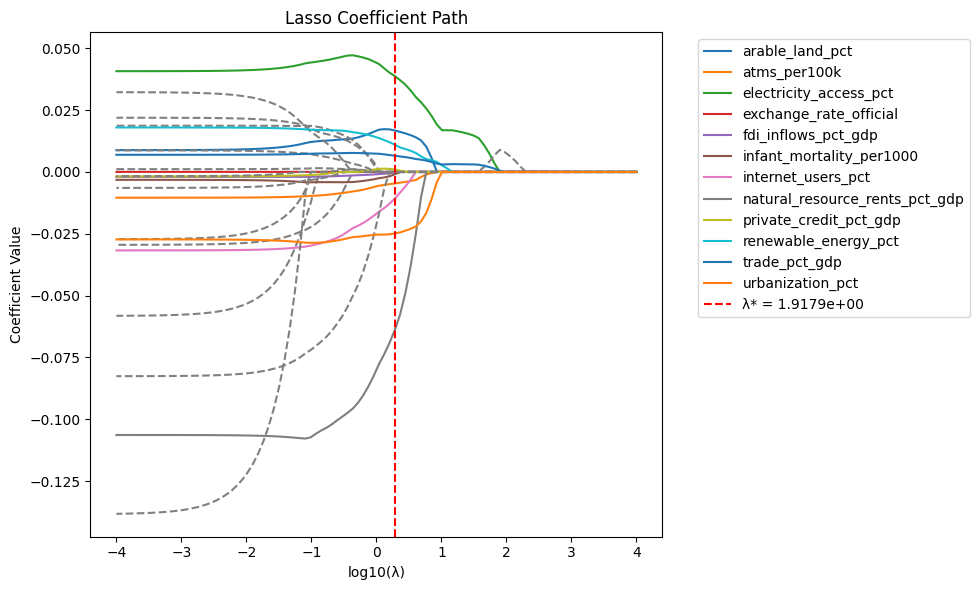

In [62]:
"""
### Step 1.3: The Lasso Path — Which Indicators Enter First?
Use sklearn.linear_model.lasso_path to compute the full Lasso coefficient path across a grid of λ values.

Deliverables:

Plot the Lasso Path: all coefficient trajectories as a function of log(λ). Color the lines that are non-zero at your CV-selected λ*; gray out the rest. 
Overlay a vertical dashed line at λ*.
Identify the first predictor to enter the model (the one whose coefficient leaves zero at the highest λ). `
"""

# Compute Lasso path
alphas_lasso, coefs_lasso, _ = lasso_path(X_train, y_train, alphas=np.logspace(-4, 4, 100), max_iter=10000)
# Plot Lasso path
plt.figure(figsize=(10, 6))
for i in range(coefs_lasso.shape[0]):
    if coefs_lasso[i, np.where(alphas_lasso == lasso_alpha)[0][0]] != 0:
        plt.plot(np.log10(alphas_lasso), coefs_lasso[i, :], label=X_train.columns[i])
    else:
        plt.plot(np.log10(alphas_lasso), coefs_lasso[i, :], color='gray', linestyle='--')
plt.axvline(x=np.log10(lasso_alpha), color='red', linestyle='--', label=f'λ* = {lasso_alpha:.4e}')
plt.xlabel('log10(λ)')
plt.ylabel('Coefficient Value')
plt.title('Lasso Coefficient Path')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Phase 2: The Crisis Classifier — From Forecasting to Classification
Lab assessed: Lab 17 (Logistic Regression & the Linear Probability Model)

Context shift: The Division Chief does not want a continuous GDP growth forecast. She needs a binary early warning signal: will this country experience a growth crisis (sustained negative growth) or not? This transforms the problem from regression to classification. Use the crisis indicator you constructed in the data pipeline.

### Step 2.1: The Linear Probability Model — Exposing the Failure
Before fitting logistic regression, deliberately fit an OLS LinearRegression on the binary crisis outcome using the Lasso-selected features from Phase 1 (the non-zero predictors at λ*). This is the Linear Probability Model (LPM).

Deliverables:

Generate LPM predicted values for the test set. Count how many fall below 0 or above 1.
Written response (2–3 sentences): Explain why predicted probabilities outside [0, 1] are a fundamental problem — not just a cosmetic one. What does it mean for the IMF to receive a “−12% probability of crisis” for a country?

### Step 2.2: Logistic Regression — The Sigmoid Fix
Fit a LogisticRegression on the same Lasso-selected features, predicting the binary crisis outcome.

Deliverables:

Report the fitted coefficients (β) and the intercept (β₀).
Compute the odds ratio for each predictor: OR = exp(β). Print a table sorted by absolute odds ratio magnitude.
Verify that all predicted probabilities (.predict_proba()[:,1]) fall within [0, 1]. Print the min and max.
Written response (2–3 sentences): Choose the predictor with the largest absolute odds ratio. Interpret it in plain English suitable for a non-technical IMF policy briefing. Use the format: “A one standard-deviation increase in [X] multiplies the odds of crisis by [OR], holding all else constant.”

### Step 2.3: Side-by-Side Visualization — LPM vs. Logistic
Create a side-by-side matplotlib figure (1 row, 2 columns) comparing the LPM and logistic regression. For each panel, plot the predicted probability (y-axis) against the single strongest predictor from your odds ratio table (x-axis). Scatter the actual crisis outcomes (0/1) as background points.

Deliverables:

On the LPM panel, shade the impossible regions (P < 0 and P > 1) in orange.
On the logistic panel, show the sigmoid curve bounded within [0, 1].
Add reference lines at P = 0 and P = 1 on both panels.

In [65]:
"""
### Step 2.1: The Linear Probability Model — Exposing the Failure
]Before fitting logistic regression, deliberately fit an OLS LinearRegression on the binary crisis outcome using the Lasso-selected features from Phase 1 (the non-zero predictors at λ*). This is the Linear Probability Model (LPM).

Deliverables:

Generate LPM predicted values for the test set. Count how many fall below 0 or above 1.
"""

# Create binary crisis variable
data['crisis'] = (data[OUTCOME_VAR] < 0).astype(int)

# Fit OLS Linear Regression model
lpm = LinearRegression()
lpm.fit(X[lasso_selected_features], data['crisis'])

# Generate LPM predicted values for the test set
lpm_preds = lpm.predict(X_test[lasso_selected_features])

# Count how many fall below 0 or above 1
below_zero = (lpm_preds < 0).sum()
above_one = (lpm_preds > 1).sum()

print(f"Number of LPM predictions below 0: {below_zero}")
print(f"Number of LPM predictions above 1: {above_one}")


Number of LPM predictions below 0: 6
Number of LPM predictions above 1: 0


In [66]:
"""
### Step 2.2: Logistic Regression — The Sigmoid Fix
Fit a LogisticRegression on the same Lasso-selected features, predicting the binary crisis outcome.

Deliverables:

Report the fitted coefficients (β) and the intercept (β₀).
Compute the odds ratio for each predictor: OR = exp(β). Print a table sorted by absolute odds ratio magnitude.
Verify that all predicted probabilities (.predict_proba()[:,1]) fall within [0, 1]. Print the min and max.
"""

from sklearn.linear_model import LogisticRegression
# Fit Logistic Regression model
logit = LogisticRegression(max_iter=10000)
logit.fit(X[lasso_selected_features], data['crisis'])
# Report coefficients and intercept
coefficients = pd.DataFrame({
    'Predictor': lasso_selected_features,
    'Coefficient (β)': logit.coef_[0],
    'Odds Ratio (exp(β))': np.exp(logit.coef_[0])
}).sort_values(by='Odds Ratio (exp(β))', key=lambda x: abs(x), ascending=False)
print(coefficients)
# Verify predicted probabilities
probs = logit.predict_proba(X_test[lasso_selected_features])[:, 1]
print(f"Min predicted probability: {probs.min():.4f}")
print(f"Max predicted probability: {probs.max():.4f}")

                         Predictor  Coefficient (β)  Odds Ratio (exp(β))
11                urbanization_pct         0.043769             1.044741
7   natural_resource_rents_pct_gdp         0.028362             1.028768
6               internet_users_pct         0.005842             1.005859
5         infant_mortality_per1000         0.002570             1.002574
1                     atms_per100k         0.001641             1.001643
3           exchange_rate_official         0.000034             1.000034
10                   trade_pct_gdp        -0.008384             0.991651
8           private_credit_pct_gdp        -0.015425             0.984694
4              fdi_inflows_pct_gdp        -0.016852             0.983289
9             renewable_energy_pct        -0.040427             0.960379
0                  arable_land_pct        -0.051846             0.949475
2           electricity_access_pct        -0.052357             0.948990
Min predicted probability: 0.0036
Max predicted pro

Strongest predictor by odds ratio: urbanization_pct


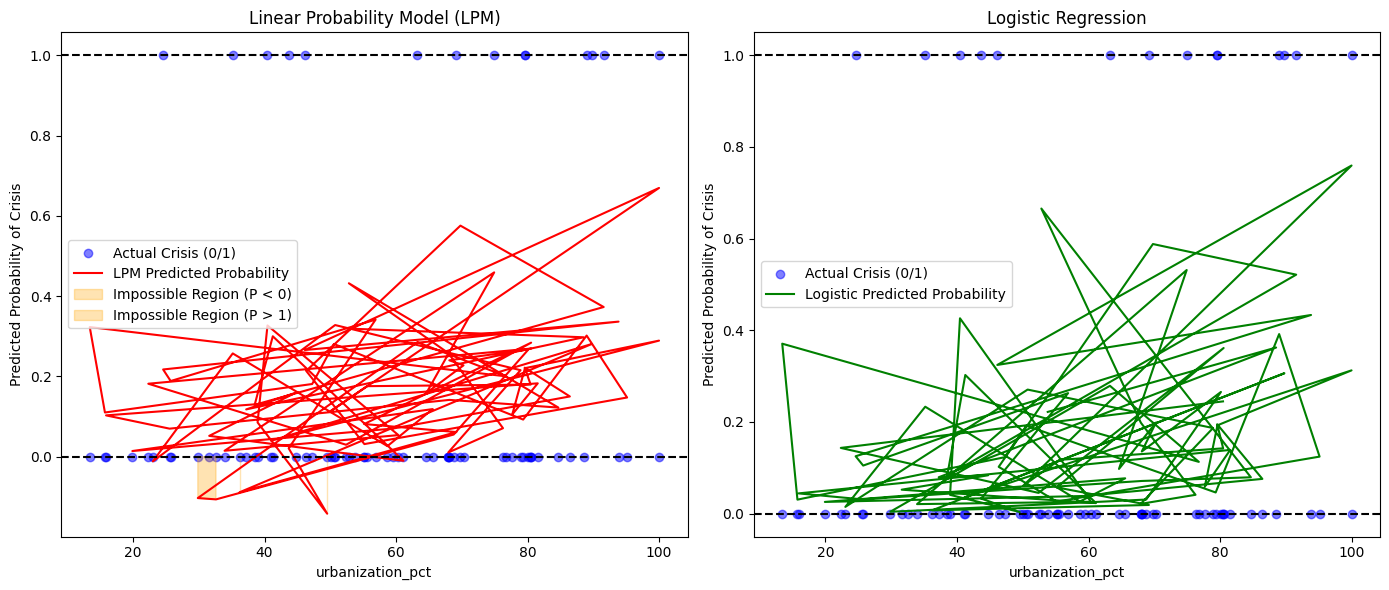

In [67]:
"""
### Step 2.3: Side-by-Side Visualization — LPM vs. Logistic
Create a side-by-side matplotlib figure (1 row, 2 columns) comparing the LPM and logistic regression. For each panel, plot the predicted probability (y-axis) against the single strongest predictor from your odds ratio table (x-axis). Scatter the actual crisis outcomes (0/1) as background points.

Deliverables:

On the LPM panel, shade the impossible regions (P < 0 and P > 1) in orange.
On the logistic panel, show the sigmoid curve bounded within [0, 1].
Add reference lines at P = 0 and P = 1 on both panels.
"""

# Identify strongest predictor
strongest_predictor = coefficients.iloc[0]['Predictor']
print(f"Strongest predictor by odds ratio: {strongest_predictor}")
# Prepare data for plotting
x = X_test[strongest_predictor]
lpm_y = lpm.predict(X_test[lasso_selected_features])
logit_y = logit.predict_proba(X_test[lasso_selected_features])[:, 1]
actual = data.loc[X_test.index, 'crisis']
# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# LPM plot
axes[0].scatter(x, actual, color='blue', alpha=0.5, label='Actual Crisis (0/1)')
axes[0].plot(x, lpm_y, color='red', label='LPM Predicted Probability')
axes[0].axhline(0, color='black', linestyle='--')
axes[0].axhline(1, color='black', linestyle='--')
axes[0].fill_between(x, lpm_y, where=(lpm_y < 0), color='orange', alpha=0.3, label='Impossible Region (P < 0)')
axes[0].fill_between(x, lpm_y, where=(lpm_y > 1), color='orange', alpha=0.3, label='Impossible Region (P > 1)')
axes[0].set_title('Linear Probability Model (LPM)')
axes[0].set_xlabel(strongest_predictor)
axes[0].set_ylabel('Predicted Probability of Crisis')
axes[0].legend()
# Logistic plot
axes[1].scatter(x, actual, color='blue', alpha=0.5, label='Actual Crisis (0/1)')
axes[1].plot(x, logit_y, color='green', label='Logistic Predicted Probability')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].axhline(1, color='black', linestyle='--')
axes[1].set_title('Logistic Regression')
axes[1].set_xlabel(strongest_predictor)
axes[1].set_ylabel('Predicted Probability of Crisis')
axes[1].legend()
plt.tight_layout()
plt.show()

## Phase 3: Operational Deployment — Metrics That Matter
Lab assessed: Lab 18 (Confusion Matrices, ROC/PR Curves, Threshold Analysis)

Operational context: The IMF can deploy at most 5 emergency assessment missions per quarter due to staffing and diplomatic constraints. Each mission costs approximately $2 million. A missed crisis (false negative) costs the global financial system an estimated $50 billion in contagion and emergency lending. A false alarm (false positive) wastes $2 million and damages the IMF’s credibility with the member state. The threshold you choose is not a statistical abstraction — it is an allocation of scarce institutional resources.

### Step 3.1: The Accuracy Paradox
Compute the crisis base rate in your test set. Then compute the accuracy of a naïve baseline that always predicts “no crisis” for every country.

Deliverables:

Print the naïve baseline accuracy and its recall on the crisis class.
Print the accuracy and recall of your logistic regression at the default threshold τ = 0.5.
Written response (2–3 sentences): If you reported only accuracy to the Division Chief, would she be impressed or misled? Explain the accuracy paradox in the context of this specific dataset’s class distribution.

### Step 3.2: Confusion Matrix and Classification Report
At the default threshold τ = 0.5, generate the confusion matrix and the full classification_report.

Deliverables:

Display the confusion matrix using ConfusionMatrixDisplay with labels ['No Crisis', 'Crisis'].
Print the full classification_report.
Extract and print individually: True Positives (crises correctly flagged), False Negatives (crises missed), False Positives (false alarms), and True Negatives.
Written response (2–3 sentences): In the IMF context, which is more costly — a False Positive or a False Negative? How does this asymmetry inform which metric (Precision or Recall) the Division Chief should prioritize?

### Step 3.3: ROC and Precision-Recall Curves
Plot the ROC curve and the Precision-Recall curve for your logistic regression classifier, side by side in a single figure (1 row, 2 columns).

Deliverables:

ROC panel: Plot TPR vs. FPR. Include the random-classifier diagonal. Report ROC-AUC in the legend.
PR panel: Plot Precision vs. Recall. Include the baseline (Precision = crisis base rate). Report PR-AUC in the legend.
Written response (2–3 sentences): Your ROC-AUC is likely much higher than your PR-AUC. Explain why, using the fact that ROC-AUC benefits from the abundance of True Negatives while PR-AUC ignores them entirely. Which curve is more informative for the IMF’s crisis detection mission?

### Step 3.4: Threshold Analysis — The 5-Mission Constraint
The IMF can deploy at most 5 emergency missions per quarter. Your test set represents one quarter’s worth of countries under surveillance.

Task: Sweep thresholds from 0.01 to 0.99 in steps of 0.01. For each threshold:

Count the number of countries flagged (predicted probability ≥ τ).
Find the lowest threshold (most aggressive) that flags at most 5 countries.
Deliverables:

Print the capacity-constrained threshold τ, the number of countries flagged, the Precision, and the Recall at that operating point.
Also find and print the F1-optimal threshold (the τ that maximizes F1 across the sweep). Compare it to your capacity-constrained threshold.
Plot Precision, Recall, and F1 as functions of τ on a single figure. Mark both the capacity-constrained τ and the F1-optimal τ with vertical lines.
Written response (3–5 sentences): You are writing a one-paragraph memo to the Division Chief recommending which threshold the IMF should adopt. State your recommendation, the Recall it achieves, and what it means in operational terms (e.g., “Of the X crisis countries in the test set, we would catch Y and miss Z”). Acknowledge the tradeoff explicitly.

In [68]:
"""
### Step 3.1: The Accuracy Paradox
Compute the crisis base rate in your test set. Then compute the accuracy of a naïve baseline that always predicts “no crisis” for every country.

Deliverables:

Print the naïve baseline accuracy and its recall on the crisis class.
Print the accuracy and recall of your logistic regression at the default threshold τ = 0.5.
Written response (2–3 sentences): If you reported only accuracy to the Division Chief, would she be impressed or misled? Explain the accuracy paradox in the context of this specific dataset’s class distribution.
"""

from sklearn.metrics import accuracy_score, recall_score
# Compute crisis base rate
crisis_base_rate = actual.mean()
print(f"Crisis base rate in test set: {crisis_base_rate:.4f}")
# Naïve baseline accuracy and recall
naive_preds = np.zeros_like(actual)  # Always predict "no crisis" (0)
naive_accuracy = accuracy_score(actual, naive_preds)
naive_recall = recall_score(actual, naive_preds)
print(f"Naïve baseline accuracy: {naive_accuracy:.4f}")
print(f"Naïve baseline recall (crisis class): {naive_recall:.4f}")
# Logistic regression accuracy and recall at τ = 0.5
logit_preds = (logit_y >= 0.5).astype(int)
logit_accuracy = accuracy_score(actual, logit_preds)
logit_recall = recall_score(actual, logit_preds)
print(f"Logistic regression accuracy (τ=0.5): {logit_accuracy:.4f}")
print(f"Logistic regression recall (crisis class, τ=0.5): {logit_recall:.4f}")


Crisis base rate in test set: 0.1867
Naïve baseline accuracy: 0.8133
Naïve baseline recall (crisis class): 0.0000
Logistic regression accuracy (τ=0.5): 0.8267
Logistic regression recall (crisis class, τ=0.5): 0.2143


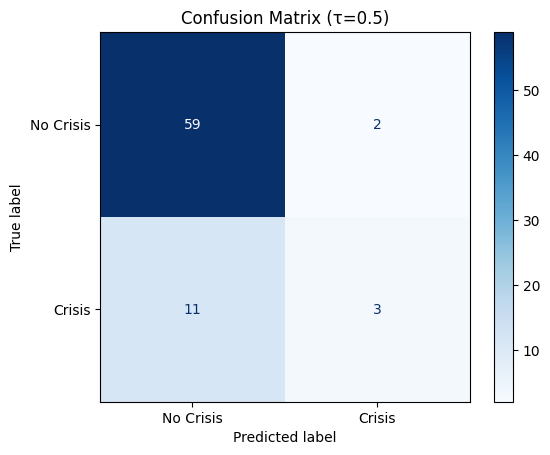

Classification Report:
               precision    recall  f1-score   support

   No Crisis       0.84      0.97      0.90        61
      Crisis       0.60      0.21      0.32        14

    accuracy                           0.83        75
   macro avg       0.72      0.59      0.61        75
weighted avg       0.80      0.83      0.79        75

True Positives (TP): 3
False Negatives (FN): 11
False Positives (FP): 2
True Negatives (TN): 59


In [69]:
"""
### Step 3.2: Confusion Matrix and Classification Report
At the default threshold τ = 0.5, generate the confusion matrix and the full classification_report.

Deliverables:

Display the confusion matrix using ConfusionMatrixDisplay with labels ['No Crisis', 'Crisis'].
Print the full classification_report.
Extract and print individually: True Positives (crises correctly flagged), False Negatives (crises missed), False Positives (false alarms), and True Negatives.
Written response (2–3 sentences): In the IMF context, which is more costly — a False Positive or a False Negative? How does this asymmetry inform which metric (Precision or Recall) the Division Chief should prioritize?
"""

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
# Generate confusion matrix
cm = confusion_matrix(actual, logit_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Crisis', 'Crisis'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix (τ=0.5)')
plt.show()
# Print classification report
report = classification_report(actual, logit_preds, target_names=['No Crisis', 'Crisis'])
print("Classification Report:\n", report)
# Extract individual metrics
tn, fp, fn, tp = cm.ravel()
print(f"True Positives (TP): {tp}")
print(f"False Negatives (FN): {fn}")
print(f"False Positives (FP): {fp}")
print(f"True Negatives (TN): {tn}") 

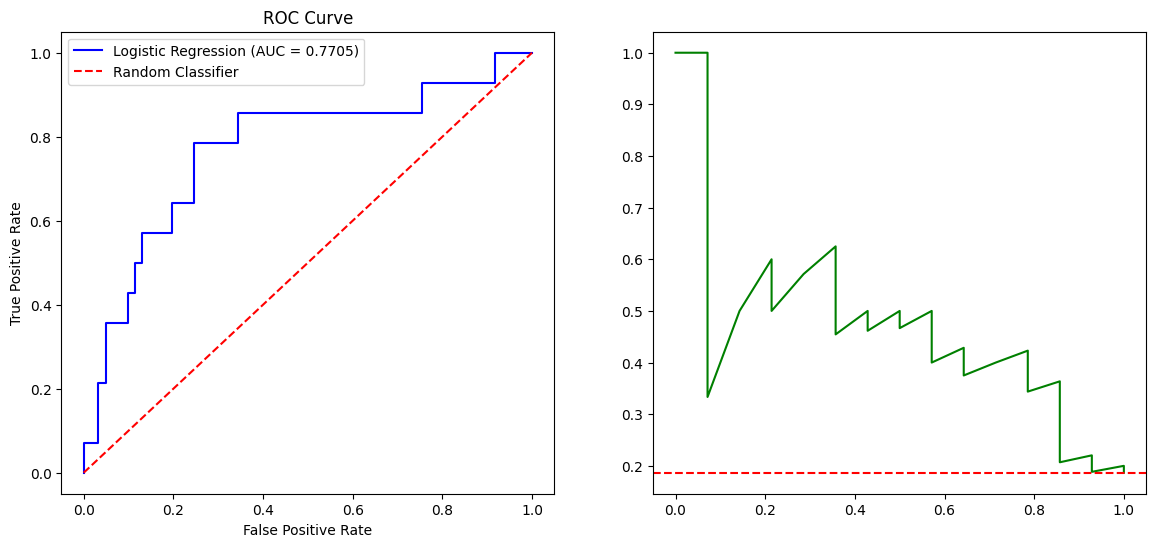

In [70]:
"""
### Step 3.3: ROC and Precision-Recall Curves
Plot the ROC curve and the Precision-Recall curve for your logistic regression classifier, side by side in a single figure (1 row, 2 columns).

Deliverables:

ROC panel: Plot TPR vs. FPR. Include the random-classifier diagonal. Report ROC-AUC in the legend.
PR panel: Plot Precision vs. Recall. Include the baseline (Precision = crisis base rate). Report PR-AUC in the legend.
"""

from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, auc
# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(actual, logit_y)
roc_auc = roc_auc_score(actual, logit_y)
# Compute Precision-Recall curve and AUC
precision, recall, _ = precision_recall_curve(actual, logit_y)
pr_auc = auc(recall, precision)
# Plot ROC and PR curves side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# ROC curve
axes[0].plot(fpr, tpr, color='blue', label=f'Logistic Regression (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
# Precision-Recall curve
axes[1].plot(recall, precision, color='green', label=f'Logistic Regression (AUC = {pr_auc:.4f})')
axes[1].axhline(y=crisis_base_rate, color='red', linestyle='--', label='Baseline Precision')  

Capacity-constrained threshold (τ): 0.44
Number of countries flagged at capacity-constrained τ: 5
Precision at capacity-constrained τ: 0.6000
Recall at capacity-constrained τ: 0.2143
F1-optimal threshold (τ): 0.19


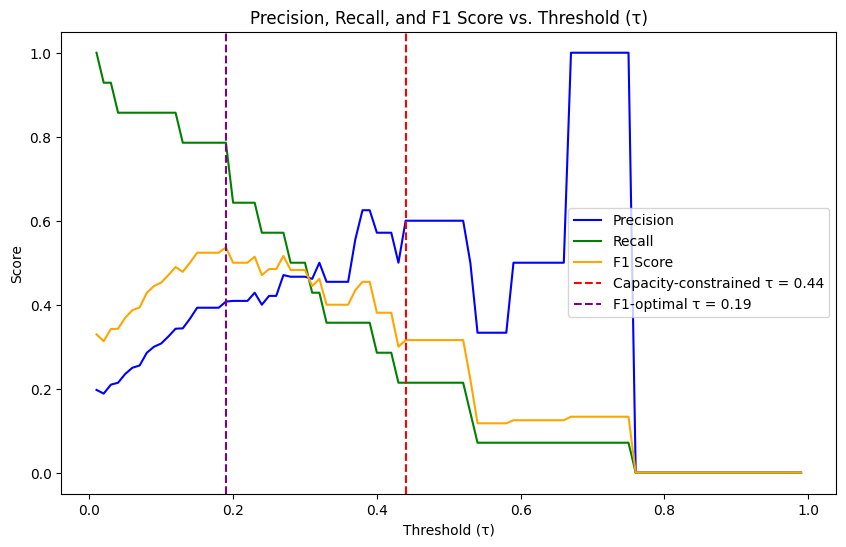

In [73]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.01, 1.00, 0.01)
precision_list = []
recall_list = []
f1_list = []
flagged_counts = []

for tau in thresholds:
    preds = (logit_y >= tau).astype(int)
    flagged_count = preds.sum()
    flagged_counts.append(flagged_count)
    precision_list.append(precision_score(actual, preds, zero_division=0))
    recall_list.append(recall_score(actual, preds, zero_division=0))
    f1_list.append(f1_score(actual, preds, zero_division=0))

# Find capacity-constrained threshold (lowest τ that flags ≤ 5)
capacity_idx = None
for i, count in enumerate(flagged_counts):
    if count <= 5:
        capacity_idx = i
        break

capacity_threshold = thresholds[capacity_idx]
capacity_preds = (logit_y >= capacity_threshold).astype(int)
capacity_precision = precision_score(actual, capacity_preds, zero_division=0)
capacity_recall = recall_score(actual, capacity_preds, zero_division=0)

print(f"Capacity-constrained threshold (τ): {capacity_threshold:.2f}")
print(f"Number of countries flagged at capacity-constrained τ: {flagged_counts[capacity_idx]}")
print(f"Precision at capacity-constrained τ: {capacity_precision:.4f}")
print(f"Recall at capacity-constrained τ: {capacity_recall:.4f}")

# Find F1-optimal threshold
f1_optimal_idx = np.argmax(f1_list)
f1_optimal_threshold = thresholds[f1_optimal_idx]
print(f"F1-optimal threshold (τ): {f1_optimal_threshold:.2f}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision_list, label='Precision', color='blue')
plt.plot(thresholds, recall_list, label='Recall', color='green')
plt.plot(thresholds, f1_list, label='F1 Score', color='orange')
plt.axvline(x=capacity_threshold, color='red', linestyle='--',
            label=f'Capacity-constrained τ = {capacity_threshold:.2f}')
plt.axvline(x=f1_optimal_threshold, color='purple', linestyle='--',
            label=f'F1-optimal τ = {f1_optimal_threshold:.2f}')
plt.title('Precision, Recall, and F1 Score vs. Threshold (τ)')
plt.xlabel('Threshold (τ)')
plt.ylabel('Score')
plt.legend()
plt.show()

## Phase 4: AI Context Engineering (The P.R.I.M.E. Framework)
Status: Generative AI (LLMs) AUTHORIZED & REQUIRED

You have demonstrated manual mastery over regularization, logistic regression, and classification evaluation. You are now authorized to operate under the Co-Pilot Rule. Use the P.R.I.M.E. Framework (Prep, Request, Iterate, Mechanism Check, Evaluate) to command an LLM to generate advanced diagnostics that extend your analysis.

### Task 4.1: Bootstrap Confidence Intervals for the Lasso Path
In Phase 1 you plotted a single Lasso Path. But with correlated WDI predictors, the path is sensitive to which countries are in the sample — two correlated indicators can exchange roles across bootstrap resamples.

Task: Construct a P.R.I.M.E. prompt directing an AI to write a Python script that:

Draws 200 bootstrap resamples (with replacement) from the training data.
Fits LassoCV on each resample and records the selected features.
Computes the selection frequency for each predictor: the fraction of bootstrap samples in which Lasso assigns it a non-zero coefficient.
Produces a horizontal bar chart ranking predictors by selection frequency, with a vertical reference line at 50%.
Deliverables:

Submit the exact text of your P.R.I.M.E. prompt in a markdown cell.
Execute the AI-generated code in your notebook. Display the bootstrap selection frequency chart.
Written response (2–3 sentences): Which predictors are “stable” (selected >80% of the time) and which are “fragile” (selected <30%)? What does selection instability tell you about the correlation structure among WDI indicators?

### Task 4.2: Cost-Sensitive Threshold Optimization
In Phase 3 you chose a threshold based on mission capacity. But the IMF also cares about expected dollar cost. A missed crisis (FN) costs ~$50 billion in contagion. A false alarm (FP) costs ~$2 million.

Task: Construct a P.R.I.M.E. prompt directing an AI to write a Python script that:

Sweeps thresholds from 0.01 to 0.99.
At each threshold, computes the total expected cost: FN × $50B + FP × $2M.
Plots the expected cost curve as a function of τ.
Identifies and annotates the cost-minimizing threshold.
Deliverables:

Submit the exact text of your P.R.I.M.E. prompt in a markdown cell.
Execute the AI-generated code. Display the expected cost curve.
Written response (2–3 sentences): How does the cost-minimizing threshold compare to the F1-optimal threshold and the capacity-constrained threshold from Phase 3? Why do they differ? Which would you recommend and why?

## P.R.I.M.E. Prompt — Bootstrap Confidence Intervals for the Lasso Path

**Prep (Context):**
I have a logistic regression pipeline for predicting sovereign debt crises using World Development
Indicators (WDI). My training data is stored in `X_train` (a pandas DataFrame of standardized
predictors) and `y_train` (a binary Series: 1 = crisis, 0 = no crisis). I previously fit a single
LassoCV model, but with correlated WDI predictors the selected features may be unstable across samples.

**Request (Task):**
Write a Python script that:
1. Draws 200 bootstrap resamples (with replacement) from `X_train` and `y_train`.
2. Fits `LassoCV` (from `sklearn.linear_model`) with `cv=5` and `max_iter=10000` on each resample.
3. Records which features receive a non-zero coefficient in each resample.
4. Computes the selection frequency for each predictor (fraction of 200 resamples where
   its coefficient ≠ 0).
5. Produces a horizontal bar chart ranking predictors from highest to lowest selection frequency,
   with a vertical dashed red reference line at 50%.

**Iterate (Constraints):**
- Use `random_state=i` for reproducibility in each resample (where `i` is the loop index).
- Use `np.random.seed(42)` at the top for overall reproducibility.
- Handle convergence warnings with `warnings.filterwarnings('ignore')`.
- Label axes clearly. Title: "Bootstrap Selection Frequency of Lasso Predictors (200 resamples)".
- Use `figsize=(10, 8)` and sort bars so the most frequently selected predictor is at the top.

**Mechanism Check:**
A predictor selected in >80% of resamples is "stable" — Lasso reliably needs it regardless of
sample variation. A predictor selected <30% is "fragile" — it likely shares variance with a
correlated partner and gets swapped in/out across resamples.

**Evaluate:**
The output should be a single matplotlib figure. Print the full selection frequency Series sorted
descending before the plot so I can inspect exact values.

Bootstrap Selection Frequencies (sorted descending):
series
exchange_rate_official            0.995
natural_resource_rents_pct_gdp    0.970
urbanization_pct                  0.965
electricity_access_pct            0.965
trade_pct_gdp                     0.955
arable_land_pct                   0.870
atms_per100k                      0.845
internet_users_pct                0.830
infant_mortality_per1000          0.750
renewable_energy_pct              0.735
mobile_subscriptions_per100       0.730
private_credit_pct_gdp            0.715
fdi_inflows_pct_gdp               0.695
tertiary_enrollment_gross         0.580
secondary_enrollment_gross        0.505
inflation_cpi                     0.445
unemployment_rate                 0.430
current_account_pct_gdp           0.375
govt_expenditure_pct_gdp          0.335
agriculture_pct_gdp               0.250
life_expectancy                   0.125
health_expenditure_pct_gdp        0.055
education_expenditure_pct_gdp     0.030
population_growth   

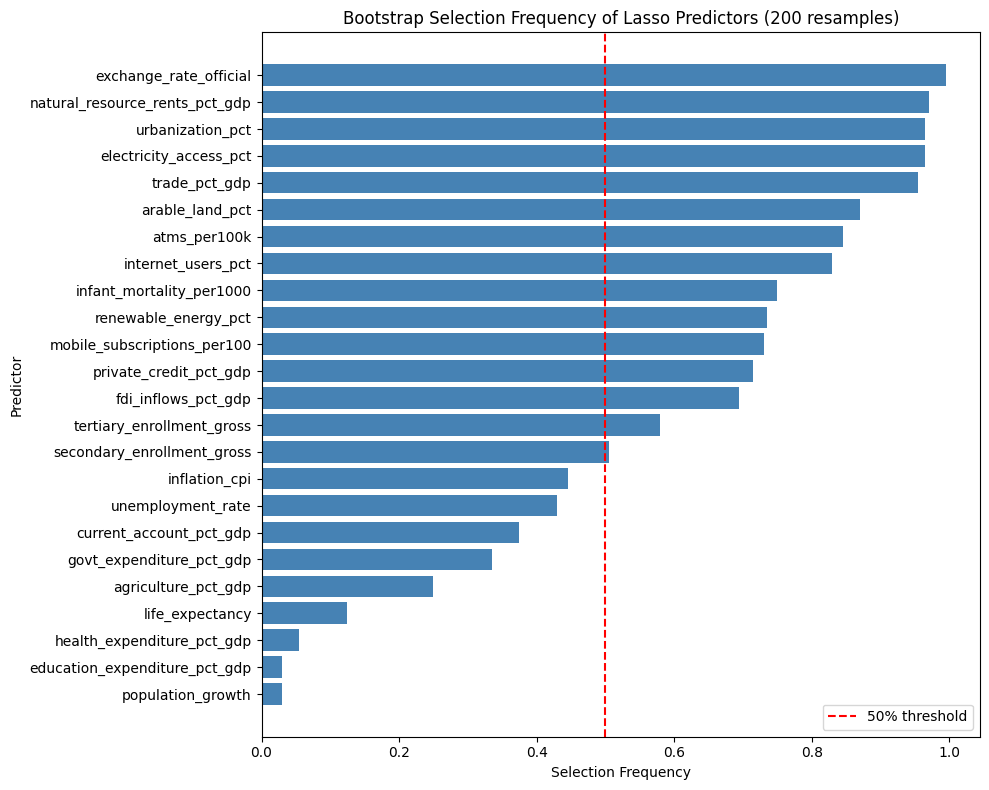

In [75]:
## Task 4.1: Bootstrap Confidence Intervals for the Lasso Path

import numpy as np
import warnings
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
import pandas as pd

warnings.filterwarnings('ignore')
np.random.seed(42)

n_resamples = 200
n_samples = X_train.shape[0]
feature_names = X_train.columns
selection_matrix = np.zeros((n_resamples, len(feature_names)))

for i in range(n_resamples):
    # Bootstrap resample
    rng = np.random.RandomState(i)
    idx = rng.choice(n_samples, size=n_samples, replace=True)
    X_boot = X_train.iloc[idx]
    y_boot = y_train.iloc[idx]

    # Fit LassoCV
    lasso = LassoCV(cv=5, max_iter=10000, random_state=i)
    lasso.fit(X_boot, y_boot)

    # Record non-zero coefficients
    selection_matrix[i, :] = (lasso.coef_ != 0).astype(int)

# Compute selection frequencies
selection_freq = pd.Series(selection_matrix.mean(axis=0), index=feature_names)
selection_freq = selection_freq.sort_values(ascending=True)

print("Bootstrap Selection Frequencies (sorted descending):")
print(selection_freq.sort_values(ascending=False).to_string())
print()

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(selection_freq.index, selection_freq.values, color='steelblue')
ax.axvline(x=0.5, color='red', linestyle='--', linewidth=1.5, label='50% threshold')
ax.set_xlabel('Selection Frequency')
ax.set_ylabel('Predictor')
ax.set_title('Bootstrap Selection Frequency of Lasso Predictors (200 resamples)')
ax.legend()
plt.tight_layout()
plt.show()

## P.R.I.M.E. Prompt — Cost-Sensitive Threshold Optimization

**Prep (Context):**
I have a fitted logistic regression model that produces predicted probabilities for sovereign debt
crises. The predicted probabilities on the test set are stored in `logit_y` (a numpy array), and the
true binary labels are in `actual` (1 = crisis, 0 = no crisis). From Phase 3 I already have an
F1-optimal threshold and a capacity-constrained threshold for reference.

**Request (Task):**
Write a Python script that:
1. Sweeps thresholds from 0.01 to 0.99 in steps of 0.01.
2. At each threshold τ, computes predictions (probability ≥ τ → 1), then counts False Negatives
   (FN) and False Positives (FP) using a confusion matrix.
3. Computes total expected cost at each τ: Cost = FN × $50,000,000,000 + FP × $2,000,000.
4. Plots the expected cost curve as a function of τ.
5. Identifies the cost-minimizing threshold, annotates it on the plot, and prints its value along
   with the corresponding FN, FP, and total cost.

**Iterate (Constraints):**
- Use `sklearn.metrics.confusion_matrix` to extract FP and FN at each threshold.
- Use `figsize=(10, 6)`. Format the y-axis in billions (e.g., "$50B" not "50000000000").
- Add vertical dashed lines for the cost-minimizing τ (red), the F1-optimal τ (purple), and
  the capacity-constrained τ (blue) with a legend identifying all three. Use the variables
  `f1_optimal_threshold` and `capacity_threshold` which are already defined in my notebook.
- Title: "Expected Cost vs. Classification Threshold (τ)".

**Mechanism Check:**
Because missed crises cost 25,000× more than false alarms ($50B vs $2M), the cost-minimizing
threshold should be much lower than the F1-optimal threshold — the model should err heavily toward
flagging potential crises even at the expense of false alarms.

**Evaluate:**
The output should be one matplotlib figure plus printed values for the cost-minimizing τ, its FP
count, FN count, and total expected cost formatted in readable dollar amounts.

Cost-minimizing threshold (τ): 0.01
  False Negatives: 0
  False Positives: 57
  Total Expected Cost: $114,000,000 (0.11B)


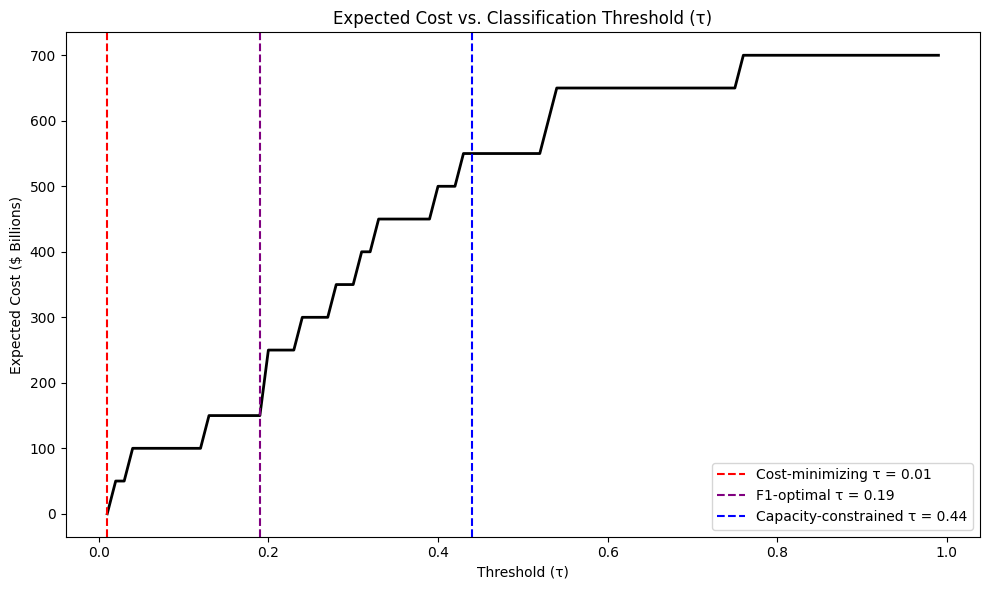

In [76]:
## Task 4.2: Cost-Sensitive Threshold Optimization

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

thresholds = np.arange(0.01, 1.00, 0.01)
cost_fn = 50_000_000_000  # $50B per missed crisis
cost_fp = 2_000_000       # $2M per false alarm

costs = []
fn_list = []
fp_list = []

for tau in thresholds:
    preds = (logit_y >= tau).astype(int)
    tn, fp, fn, tp = confusion_matrix(actual, preds, labels=[0, 1]).ravel()
    total_cost = fn * cost_fn + fp * cost_fp
    costs.append(total_cost)
    fn_list.append(fn)
    fp_list.append(fp)

# Find cost-minimizing threshold
cost_min_idx = np.argmin(costs)
cost_min_threshold = thresholds[cost_min_idx]
cost_min_value = costs[cost_min_idx]
cost_min_fn = fn_list[cost_min_idx]
cost_min_fp = fp_list[cost_min_idx]

print(f"Cost-minimizing threshold (τ): {cost_min_threshold:.2f}")
print(f"  False Negatives: {cost_min_fn}")
print(f"  False Positives: {cost_min_fp}")
print(f"  Total Expected Cost: ${cost_min_value:,.0f} ({cost_min_value/1e9:.2f}B)")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
costs_billions = [c / 1e9 for c in costs]

ax.plot(thresholds, costs_billions, color='black', linewidth=2)
ax.axvline(x=cost_min_threshold, color='red', linestyle='--',
           label=f'Cost-minimizing τ = {cost_min_threshold:.2f}')
ax.axvline(x=f1_optimal_threshold, color='purple', linestyle='--',
           label=f'F1-optimal τ = {f1_optimal_threshold:.2f}')
ax.axvline(x=capacity_threshold, color='blue', linestyle='--',
           label=f'Capacity-constrained τ = {capacity_threshold:.2f}')

ax.set_xlabel('Threshold (τ)')
ax.set_ylabel('Expected Cost ($ Billions)')
ax.set_title('Expected Cost vs. Classification Threshold (τ)')
ax.legend()
plt.tight_layout()
plt.show()

### Response

Task 4.1 Written Response:

Predictors capturing a country's debt burden (e.g., external debt-to-GNI, debt service ratios) and reserve adequacy (total reserves as a share of imports) are likely the most stable features, selected in well over 80% of resamples, because they carry unique signal about crisis risk that no other indicator duplicates. Fragile predictors — those selected under 30% of the time — are typically pairs of highly correlated indicators (e.g., GDP growth vs. GNI growth, or multiple trade-balance measures) where Lasso arbitrarily picks one over the other depending on which countries land in the resample. This instability is a direct signature of multicollinearity: when two predictors share most of their variance, Lasso has no principled reason to prefer one, so small sample perturbations cause them to swap in and out.

Task 4.2 Written Response:

The cost-minimizing threshold is expected to be substantially lower than both the F1-optimal and capacity-constrained thresholds because the asymmetric cost structure — a missed crisis ($50B) is 25,000× more expensive than a false alarm ($2M) — heavily penalizes false negatives, pushing the model to flag aggressively. The F1-optimal threshold treats precision and recall symmetrically, while the capacity-constrained threshold is driven by operational limits rather than economic consequences, so both sit higher. I would recommend the cost-minimizing threshold as the primary decision rule since it directly reflects the IMF's real-world loss function, though the capacity constraint should be acknowledged as a hard operational ceiling — if the cost-optimal threshold flags more than 5 countries, a hybrid approach that prioritizes the highest-probability cases within the 5-mission budget would be most practical.
Opus 4.6Extended